# Normalization of data

Here we implement multiple methods for predicting total waste and total impurities from select variables from processed time series data containing manufacturing parameters. Based on all of the features, we discretionarily chose 7 variables (based on our prior knowledge as chemical engineering students) that are most likely going to affect waste and impurity formation in the manufacturing design process. Variables were preprocessed through normalization and outlier removal. Then, target variables were log transformed. Multiple models were created, including poylnomial regression, random forest, support vector regression (SVR), elastic net, and XGBoost. Global and local interpretation techniques such as feature importance and SHAP values were utilized for model transparency. 

In [1]:
'''
Date <12/10/2025>
Written by <Ricky Kim> <kk3764@columbia.edu>
The code has not been generated by AI tools, or copied from an external resource
'''

import pandas as pd

# Load CSV file as a DataFrame
normalization = pd.read_csv("data/Normalization.csv", delimiter=";")
process_full = pd.read_csv("data/Process.csv", delimiter=";")

# Select design/target variables
process_raw = process_full.iloc[:, [0,1,5,13,14,17,19,23,26,28,32]]

# Merge normalization factors into process data on product code
process = process_raw.merge(
    normalization[['Product code', 'Normalisation factor']],
    how='left',
    left_on='code',
    right_on='Product code'
)

batch_dependent_vars = [
    'total_waste',
    'tbl_fill_mean',
    'cyl_height_mean',
    'Startup_tbl_fill_maxDifference',
    'Startup_tbl_fill_mean'
]

# Normalize batch-dependent variables
for var in batch_dependent_vars:
    process[var] = process[var] / process['Normalisation factor']

# Drop unnecessary columns
process.drop(columns=['batch', 'code', 'Product code', 'Normalisation factor'], inplace=True)

final_columns = [
    'tbl_fill_mean',
    'cyl_height_mean',
    'Startup_tbl_fill_mean',
    'Startup_tbl_fill_maxDifference',
    'ejection_mean',
    'main_CompForce mean',
    'main_CompForce_sd',
    'Total impurities',
    'total_waste'
]

# Reorder columns
process = process[final_columns]
print(process.head())

   tbl_fill_mean  cyl_height_mean  Startup_tbl_fill_mean  \
0       2.221770         0.874777               2.277778   
1       2.208138         0.877196               2.214773   
2       2.212957         0.880418               2.184167   
3       2.212495         0.876886               2.175521   
4       2.216512         0.885978               2.180417   

   Startup_tbl_fill_maxDifference  ejection_mean  main_CompForce mean  \
0                        0.158333     223.319255             4.255404   
1                        0.075000     215.963899             4.251023   
2                        0.050000     212.530393             4.261263   
3                        0.100000     225.938922             4.357605   
4                        0.079167     237.305389             4.249461   

   main_CompForce_sd  Total impurities  total_waste  
0           0.058473              0.33   885.590278  
1           0.056788              0.34   369.791667  
2           0.054522              0.28

# DBSCAN clustering with PCA to identify outliers

Best eps: 1.8, Best min_samples: 20, Best silhouette: 0.568


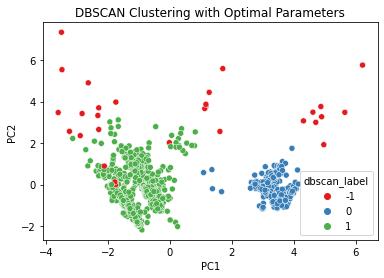

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# Drop rows with missing values
process = process.dropna()

design_vars = [
    'tbl_fill_mean',
    'cyl_height_mean',
    'Startup_tbl_fill_mean',
    'Startup_tbl_fill_maxDifference',
    'ejection_mean',
    'main_CompForce mean',
    'main_CompForce_sd'
]

# Scale design variables
X = process[design_vars]
X_scaled = StandardScaler().fit_transform(X)

# Fine-tune hyperparamters for DBSCAN
eps_values = [0.5, 0.8, 1.0, 1.2, 1.5, 1.8]
min_samples_values = [5, 10, 14, 20, 25]

best_eps, best_min_samples, best_silhouette = 0, 0, -1

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        # Ensure valid clustering
        if len(set(labels)) > 1 and len(set(labels)) != len(X):
            silhouette_avg = silhouette_score(X_scaled, labels)

            if silhouette_avg > best_silhouette:
                best_silhouette = silhouette_avg
                best_eps = eps
                best_min_samples = min_samples

print(f"Best eps: {best_eps}, Best min_samples: {best_min_samples}, Best silhouette: {best_silhouette:.3f}")

# Train DBSCAN with the best hyperparameters
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels = dbscan.fit_predict(X_scaled)
process['dbscan_label'] = labels

# Visualize clusters in PCA space
process[['PC1', 'PC2']] = PCA(n_components=2).fit_transform(X_scaled)
sns.scatterplot(data=process, x='PC1', y='PC2', hue='dbscan_label', palette='Set1')
plt.title("DBSCAN Clustering with Optimal Parameters")
plt.show()

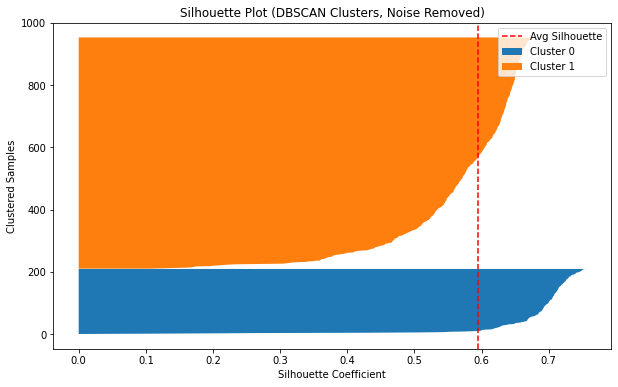

In [3]:
from sklearn.metrics import silhouette_samples
import numpy as np

# Remove outliers (= -1 label)
mask = process['dbscan_label'] != -1
X_scaled_clean = X_scaled[mask]
labels_clean = process.loc[mask, 'dbscan_label'].values

# Compute silhouette scores
silhouette_vals = silhouette_samples(X_scaled_clean, labels_clean)
process_clean = process[mask].reset_index(drop=True)
process_clean['silhouette'] = silhouette_vals

# Plot silhouette diagram
cluster_labels = sorted(np.unique(labels_clean))
y_lower = 0

plt.figure(figsize=(10, 6))

for label in cluster_labels:
    label_silhouette = process_clean[process_clean['dbscan_label'] == label]['silhouette'].values
    label_silhouette.sort()

    size = len(label_silhouette)
    y_upper = y_lower + size
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, label_silhouette, label=f"Cluster {label}")
    y_lower = y_upper

plt.axvline(x=np.mean(silhouette_vals), color="red", linestyle="--", label="Avg Silhouette")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Clustered Samples")
plt.title("Silhouette Plot (DBSCAN Clusters, Noise Removed)")
plt.legend()
plt.show()

In [4]:
# Drop columns related to clustering
process = process_clean.drop(columns=['dbscan_label', 'PC1', 'PC2', 'silhouette'])
print(process.head())

   tbl_fill_mean  cyl_height_mean  Startup_tbl_fill_mean  \
0       2.221770         0.874777               2.277778   
1       2.208138         0.877196               2.214773   
2       2.212957         0.880418               2.184167   
3       2.212495         0.876886               2.175521   
4       2.216512         0.885978               2.180417   

   Startup_tbl_fill_maxDifference  ejection_mean  main_CompForce mean  \
0                        0.158333     223.319255             4.255404   
1                        0.075000     215.963899             4.251023   
2                        0.050000     212.530393             4.261263   
3                        0.100000     225.938922             4.357605   
4                        0.079167     237.305389             4.249461   

   main_CompForce_sd  Total impurities  total_waste  
0           0.058473              0.33   885.590278  
1           0.056788              0.34   369.791667  
2           0.054522              0.28

# Multicolinearity identification

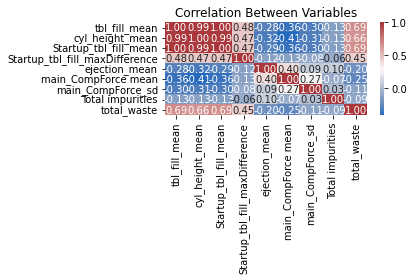

In [5]:
# Plot correlation heatmap
sns.heatmap(process.corr(), annot=True, cmap='vlag', fmt=".2f")
plt.title("Correlation Between Variables")
plt.tight_layout()
plt.show()

In [6]:
# Dimensionality reduction using PCA
process_original = process.copy()
pca = PCA(n_components=1)

# Create a new variable called 'tbl_fill_depth'
process['tbl_fill_depth'] = pca.fit_transform(process[['tbl_fill_mean', 'cyl_height_mean', 'Startup_tbl_fill_mean']])

final_columns = [
    'tbl_fill_depth',
    'tbl_fill_mean',
    'cyl_height_mean',
    'Startup_tbl_fill_mean',
    'Startup_tbl_fill_maxDifference',
    'ejection_mean',
    'main_CompForce mean',
    'main_CompForce_sd',
    'Total impurities',
    'total_waste'
]

# Reorder columns
process = process[final_columns]

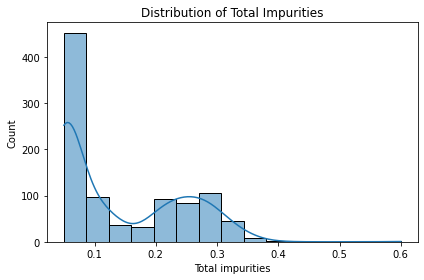

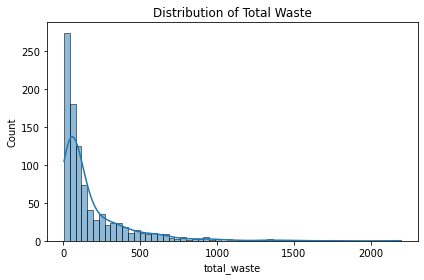

In [7]:
# Plot the distribution of target variables
title_map = {'Total impurities': 'Total Impurities', 'total_waste': 'Total Waste'}
for target in ['Total impurities', 'total_waste']:
    sns.histplot(process[target], kde=True)
    plt.title(f"Distribution of {title_map[target]}")
    plt.tight_layout()
    plt.show()

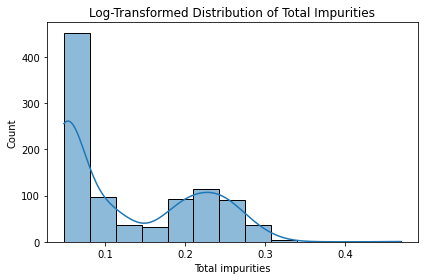

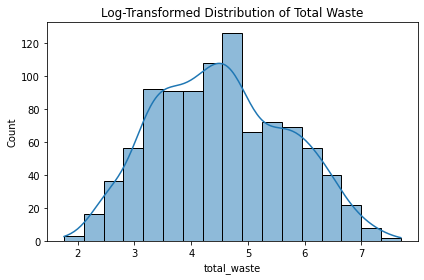

In [8]:
# Plot log-transformed distribution of target variables
for target in ['Total impurities', 'total_waste']:
    log_data = np.log1p(process[target])    # log(1 + x) to handle zeroes
    sns.histplot(log_data, kde=True)
    plt.title(f"Log-Transformed Distribution of {title_map[target]}")
    plt.tight_layout()
    plt.show()

In [9]:
# Apply log transformation to remove skewness
process['total_waste'] = np.log1p(process['total_waste'])

# Print basic statistical summary
summary_table = process.describe().loc[['mean', 'std', 'min', 'max']]
print(summary_table)

      tbl_fill_depth  tbl_fill_mean  cyl_height_mean  Startup_tbl_fill_mean  \
mean    2.979215e-17       0.945390         0.309650               0.933274   
std     1.035446e+00       0.709340         0.265646               0.707085   
min    -1.148219e+00       0.149432         0.026672               0.151925   
max     2.118091e+00       2.411277         0.912357               2.396667   

      Startup_tbl_fill_maxDifference  ejection_mean  main_CompForce mean  \
mean                        0.052436     181.199339             5.985233   
std                         0.044761      80.537028             1.804789   
min                         0.000000       0.000000             2.459359   
max                         0.312500     483.047715            12.865503   

      main_CompForce_sd  Total impurities  total_waste  
mean           0.130956          0.141604     4.538514  
std            0.133775          0.099500     1.149730  
min            0.046472          0.050000     1.7576

# Linear regression for Total Waste

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

design_vars = [
    'tbl_fill_depth',
    'Startup_tbl_fill_maxDifference',
    'ejection_mean',
    'main_CompForce mean',
    'main_CompForce_sd'
]
target_var = 'total_waste'

# Select design variables for linear regression
X_tw = process[design_vars]
y_tw = process[target_var]

# Split data
X_train_tw, X_test_tw, y_train_tw, y_test_tw = train_test_split(
    X_tw, y_tw,
    test_size=0.2,
    random_state=42
)

# Perform linear regression
linear_model = LinearRegression()
linear_model.fit(X_train_tw, y_train_tw)
linear_r2 = linear_model.score(X_test_tw, y_test_tw)

# Print results
print(f"Linear Regression R²: {linear_r2:.4f}")

Linear Regression R²: 0.6832


# Nonlinear models for Total Waste

In [11]:
from utils.nonlinear import *

design_vars = [
    'tbl_fill_mean',
    'cyl_height_mean',
    'Startup_tbl_fill_mean',
    'Startup_tbl_fill_maxDifference',
    'ejection_mean',
    'main_CompForce mean',
    'main_CompForce_sd'
]

# Exclude the PCA variable for nonlinear models
X_tw = process[design_vars]
y_tw = process[target_var]

# Split data
X_train_tw, X_test_tw, y_train_tw, y_test_tw = train_test_split(
    X_tw, y_tw,
    test_size=0.2,
    random_state=42
)

# Perform polynomial regression with degree of 2
poly_tw = polynomial_regression(X_train_tw, X_test_tw, y_train_tw, y_test_tw)

# Random Forest hyperparameters
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}
rf_tw = random_forest(X_train_tw, X_test_tw, y_train_tw, y_test_tw, rf_params)

# SVR hyperparameters
svr_params = {
    'svr__kernel': ['rbf'],
    'svr__C': [1, 10],
    'svr__gamma': ['scale']
}
svr_tw = svr(X_train_tw, X_test_tw, y_train_tw, y_test_tw, svr_params)

# Elastic Net hyperparameters
en_params = {
    'poly__degree': [1, 2],
    'elastic__alpha': [0.01, 0.1, 1],
    'elastic__l1_ratio': [0.2, 0.5, 0.8]
}
en_tw = elastic_net(X_train_tw, X_test_tw, y_train_tw, y_test_tw, en_params)

# XGBoost hyperparameters
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'colsample_bytree': [0.8, 1.0],
    'subsample': [1.0],
    'reg_alpha': [0],
    'reg_lambda': [1]
}
xgb_tw = xgb(X_train_tw, X_test_tw, y_train_tw, y_test_tw, xgb_params)

Polynomial Regression (deg 2) R²: 0.7608

Random Forest Test Performance:
Best R² Score: 0.8044
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

SVR Test Performance:
Best R² Score: 0.7559
Best Parameters: {'svr__C': 1, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'}

Elastic Net Test Performance:
Best R² Score: 0.7621
Best Parameters: {'elastic__alpha': 0.01, 'elastic__l1_ratio': 0.2, 'poly__degree': 2}

XGBoost Test Performance:
Best R² Score: 0.8031
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 1.0}


# Nonlinear models for Total Impurities

In [12]:
# Define target variable
target_var = 'Total impurities'

X_ti = process[design_vars]
y_ti = process[target_var]

# Split data
X_train_ti, X_test_ti, y_train_ti, y_test_ti = train_test_split(
    X_ti, y_ti,
    test_size=0.2,
    random_state=42
)

# Perform polynomial regression with degree of 2
poly_ti = polynomial_regression(X_train_ti, X_test_ti, y_train_ti, y_test_ti)

# Random Forest hyperparameters
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt']
}
rf_ti = random_forest(X_train_ti, X_test_ti, y_train_ti, y_test_ti, rf_params)

# SVR hyperparameters
svr_params = {
    'svr__kernel': ['rbf'],
    'svr__C': [10, 100],
    'svr__gamma': ['scale']
}
svr_ti = svr(X_train_ti, X_test_ti, y_train_ti, y_test_ti, svr_params)

# Elastic Net hyperparameters
en_params = {
    'poly__degree': [1, 2],
    'elastic__alpha': [0.01, 0.1, 1],
    'elastic__l1_ratio': [0.2, 0.5, 0.8]
}
en_ti = elastic_net(X_train_ti, X_test_ti, y_train_ti, y_test_ti, en_params)

# XGBoost hyperparameters
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'colsample_bytree': [0.8, 1.0],
    'subsample': [1.0],
    'reg_alpha': [0.1, 1],
    'reg_lambda': [1, 10, 20]
}
xgb_ti = xgb(X_train_ti, X_test_ti, y_train_ti, y_test_ti, xgb_params)

Polynomial Regression (deg 2) R²: 0.1892

Random Forest Test Performance:
Best R² Score: 0.6175
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

SVR Test Performance:
Best R² Score: 0.203
Best Parameters: {'svr__C': 10, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'}

Elastic Net Test Performance:
Best R² Score: 0.0801
Best Parameters: {'elastic__alpha': 0.01, 'elastic__l1_ratio': 0.2, 'poly__degree': 2}

XGBoost Test Performance:
Best R² Score: 0.588
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 1.0}


# Define new design variables

In [13]:
# Perform feature engineering to evaluate the interactions between various features
process_original['fill_startup_delta'] = abs(process_original['Startup_tbl_fill_mean'] - process_original['tbl_fill_mean'])
process_original['ejection_force_x_fill'] = process_original['ejection_mean'] * process_original['tbl_fill_mean']
process_original['fill_x_cyl'] = process_original['tbl_fill_mean'] * process_original['cyl_height_mean']

print(process_original.head())

   tbl_fill_mean  cyl_height_mean  Startup_tbl_fill_mean  \
0       2.221770         0.874777               2.277778   
1       2.208138         0.877196               2.214773   
2       2.212957         0.880418               2.184167   
3       2.212495         0.876886               2.175521   
4       2.216512         0.885978               2.180417   

   Startup_tbl_fill_maxDifference  ejection_mean  main_CompForce mean  \
0                        0.158333     223.319255             4.255404   
1                        0.075000     215.963899             4.251023   
2                        0.050000     212.530393             4.261263   
3                        0.100000     225.938922             4.357605   
4                        0.079167     237.305389             4.249461   

   main_CompForce_sd  Total impurities  total_waste  fill_startup_delta  \
0           0.058473              0.33   885.590278            0.056008   
1           0.056788              0.34   369.79166

In [14]:
design_vars = [
    'tbl_fill_mean',
    'cyl_height_mean',
    'Startup_tbl_fill_mean',
    'Startup_tbl_fill_maxDifference',
    'ejection_mean',
    'main_CompForce mean',
    'main_CompForce_sd',
    'fill_startup_delta',
    'ejection_force_x_fill',
    'fill_x_cyl'
]

X_ti_new = process_original[design_vars]
y_ti_new = process_original[target_var]

# Split data
X_train_ti_new, X_test_ti_new, y_train_ti_new, y_test_ti_new = train_test_split(
    X_ti_new, y_ti_new,
    test_size=0.2,
    random_state=42
)

# Compute R2 for the best performing models (RF and XGBoost)
rf_ti_new = random_forest(X_train_ti_new, X_test_ti_new, y_train_ti_new, y_test_ti_new, rf_params)
xgb_ti_new = xgb(X_train_ti_new, X_test_ti_new, y_train_ti_new, y_test_ti_new, xgb_params)



Random Forest Test Performance:
Best R² Score: 0.6027
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

XGBoost Test Performance:
Best R² Score: 0.5948
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 1.0}


# Global interpretation of the best performing models

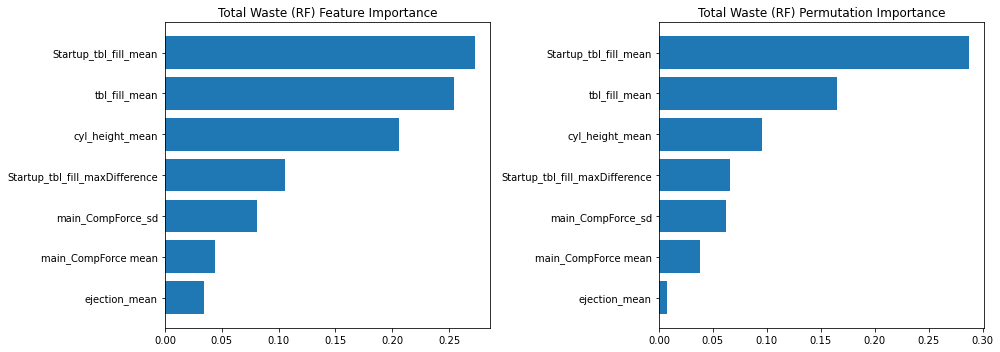

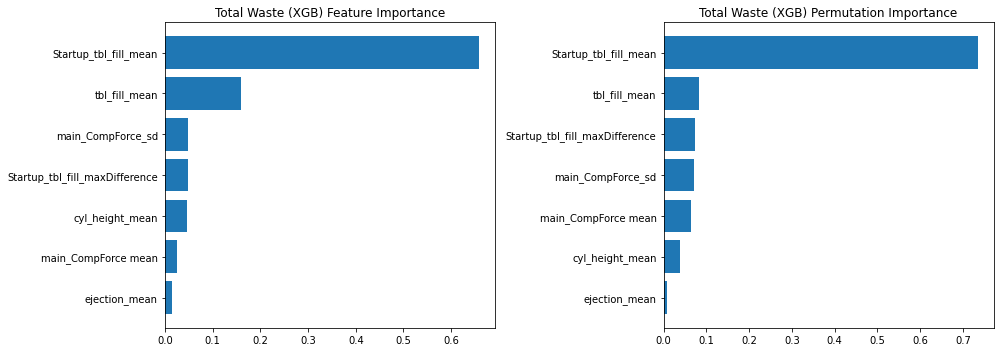

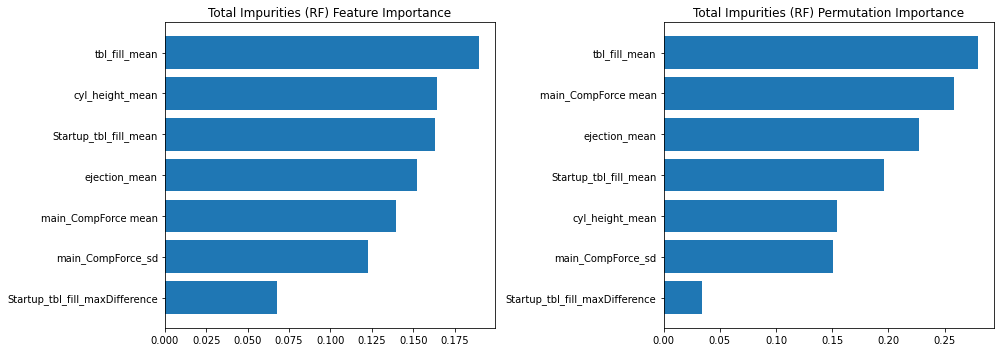

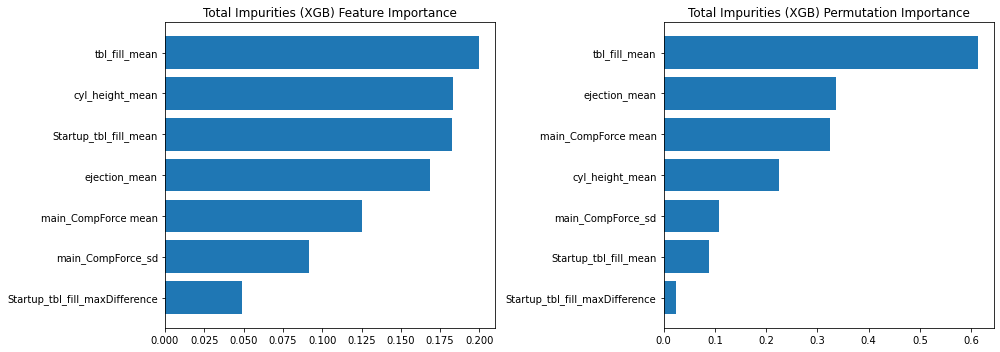

In [15]:
from sklearn.inspection import permutation_importance

def plot_global_interpretation(model, X_test, y_test, title):
    # Rank feature importance in decreasing order
    f_result = model.feature_importances_
    sorted_idx_f = np.argsort(f_result)[::-1]

    # Rank permutation importance in decreasing order
    p_result = permutation_importance(
        model, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1
    )
    p_result_mean = p_result.importances_mean
    sorted_idx_p = np.argsort(p_result_mean)[::-1]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    feature_names = X_test.columns

    # Plot feature importance
    axes[0].barh(np.array(feature_names)[sorted_idx_f], f_result[sorted_idx_f])
    axes[0].set_title(f'{title} Feature Importance')
    axes[0].invert_yaxis()

    # Plot permutation importance
    axes[1].barh(np.array(feature_names)[sorted_idx_p], p_result_mean[sorted_idx_p])
    axes[1].set_title(f'{title} Permutation Importance')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()
    
plot_global_interpretation(rf_tw, X_test_tw, y_test_tw, 'Total Waste (RF)')
plot_global_interpretation(xgb_tw, X_test_tw, y_test_tw, 'Total Waste (XGB)')
plot_global_interpretation(rf_ti, X_test_ti, y_test_ti, 'Total Impurities (RF)')
plot_global_interpretation(xgb_ti, X_test_ti, y_test_ti, 'Total Impurities (XGB)')